# A runnable demo: using the trained Electome Factor models

This notebook is a short, runnable walkthrough of how to use the six paper-active Electome Factor (EF) models shipped in `models/`. It is designed to be self-contained — you do **not** need any of the lab data files on RDSS to run it. A tiny LFP-shaped simulated dataset shipped in `examples/demo_data/` so every cell below executes in seconds.

What you'll do here:

1. **Pick an EF** out of the six and load it with one call.
2. **Project** simulated LFP-spectral windows through the encoder to obtain loading scores `s[:, 0]`.
3. **Compute per-mouse AUC** of those scores against a binary label
   (the simulated `onnest_label`).
4. **Inspect the feature space** with a scree plot of the cumulative
   squared-L2 contribution of factor 0.
5. **Visualize the selected features** with the dual-filter bar (3-band)
   or dot (1-Hz) heatmap — automatically chosen based on the model's
   frequency resolution.

For the full training pipeline (Stage-1 LOO hyperparameter selection,
Stage-2 pure LOO AUC reporting, and Stage-3 paper-model training) see the
six task notebooks in `notebooks/` — each follows the same 8-section
structure described in the top-level `README.md`.

In [1]:
# `electome` is pip-installed via `pip install -e .` so it imports
# from anywhere. We still add `examples/` to sys.path so the demo
# data fixture (`demo_data/__init__.py`) can be imported by name.
import sys, os
_examples = os.path.dirname(os.path.abspath('demo.ipynb' if os.path.exists('demo.ipynb')
                                            else os.path.join('examples', 'demo.ipynb')))
if _examples not in sys.path:
    sys.path.insert(0, _examples)

import numpy as np
import matplotlib.pyplot as plt

## Section 2. The six EF models

Each of the six task notebooks in `notebooks/` produces one frozen
`.pt` model, all of which live in `models/`. The table below summarizes
what each one is for; see `models/README.md` for full per-model
hyperparameter details and the old-vs-new filename mapping.

| Filename in `models/` | EF | Task | Frequency resolution |
| --- | --- | --- | --- |
| `OnnestVsOffnest_3band.pt` | Maternal Engagement | On-nest vs off-nest LFP windows | 3 wide bands |
| `OnnestVsOffnest_1Hz.pt` | Maternal Engagement | On-nest vs off-nest LFP windows | 54 × 1-Hz bins |
| `LickingVsNonLicking_3band.pt` | Licking | Licking vs non-licking (within on-nest) | 3 wide bands |
| `LickingVsGrooming_3band.pt` | Licking-vs-Grooming | Licking vs self-grooming (within on-nest) | 3 wide bands |
| `PreVsPost134_3band.pt` | Maternal Stage | Pre home vs P1/P3/P4 home | 3 wide bands |
| `PreVsPost134_1Hz.pt` | Maternal Stage | Pre home vs P1/P3/P4 home | 54 × 1-Hz bins |

In [2]:
from electome.models_registry import list_ef_models, get_model_info

for name in list_ef_models():
    info = get_model_info(name)
    print(f'  {name:30s}  {info["ef_name"]}')


  OnnestVsOffnest_3band           Maternal Engagement (3-band)
  OnnestVsOffnest_1Hz             Maternal Engagement (1 Hz)
  LickingVsNonLicking_3band       Licking (within on-nest)
  LickingVsGrooming_3band         Licking vs Grooming
  PreVsPost134_3band              Maternal Stage (3-band)
  PreVsPost134_1Hz                Maternal Stage (1 Hz)


## Section 3. Load an EF model

Loading any of the six is a single call to `load_ef_model(name)`. The
function locates `models/` for you (regardless of whether you launch
Jupyter from `examples/`, from the repo root, or from `notebooks/`) and
unpickles the model object directly onto CPU.

For the rest of this walkthrough we'll use the 3-band Maternal-Engagement
EF — it's the smallest model and the easiest to interpret. At the very
end of the notebook we'll also load the 1-Hz version to show how the
element-selection heatmap switches from bars to dots.

In [3]:
from electome.models_registry import load_ef_model

model = load_ef_model('OnnestVsOffnest_3band')
print(f'h = {model.h}')
print(f'dim_in = {model.dim_in}')
print(f'n_components = {model.n_components}')
print(f'sup_weight (μ) = {model.sup_weight}')


h = 64
dim_in = 108
n_components = 10
sup_weight (μ) = 0.05


## Section 4. Load the simulated demo dataset

The dataset is intentionally tiny — **3 fake mice × 50 windows each = 150 windows** spread across five maternal stages (`Pre`, `P1`, `P3`, `P8`, `P14`). Features follow LFP-shaped distributions (lognormal per-band power, beta-distributed squared coherence) so the loaded model actually produces meaningful scores instead of NaNs.

Only windows whose `period` is in `{P1, P3, P8}` carry an `onnest_label` (`np.nan` elsewhere) — the on-nest classification task is only meaningful at active maternal-care stages, so labels are only present there. For windows with `onnest_label == 1` the generator boosted the 2-7 Hz (theta) band on every region and every region-pair; that is the only systematic signal in the file.

The dataset is shipped as a pair of pre-generated pickle fixtures in `examples/demo_data/` (one `demo_3band.pkl`, one `demo_1Hz.pkl`); every reader loads the same bytes off disk. `examples/demo_data/generate.py` is the one-shot script that produced them — re-run only if you want to regenerate the fixture.

In [4]:
from demo_data import load_demo_data

data = load_demo_data('3band')

print(f'X shape       : {data["X"].shape}  (expected (N, dim_in) = (150, {model.dim_in}))')
print(f'mice          : {sorted(set(data["mouse_id"]))}')
print(f'stages        : {sorted(set(data["period"]))}')
print(f'with onnest y : {int((~np.isnan(data["onnest_label"])).sum())}/{len(data["mouse_id"])} windows')

X shape       : (150, 108)  (expected (N, dim_in) = (150, 108))
mice          : ['SimMouse_01', 'SimMouse_02', 'SimMouse_03']
stages        : ['P1', 'P14', 'P3', 'P8', 'Pre']
with onnest y : 90/150 windows


## Section 5. Backprojection and per-mouse AUC

`compute_loading_scores(model, X)` takes a loaded EF model and a feature matrix `X` of shape `(N, model.dim_in)` and returns an array of `N` loading scores — one number per window — for factor 0, the supervised latent factor that the EF is built around. A higher score means the window looks more like the "positive" class the model was trained to detect (e.g. on-nest behavior for the Maternal-Engagement EF).

`compute_per_mouse_auc(scores, y_true, mouse_ids)` then computes the ROC-AUC of those scores against the binary label, separately for each mouse, skipping any mouse that ends up single-class after dropping NaN labels.

Note: this is simulated data, so the AUC is mainly a sanity-check that the loading-score pipeline runs end-to-end. Two things can move it: how much the EF's encoder relies on the 2-7 Hz (theta) band where the demo signal was injected, and the encoder's sign convention (some EFs are trained so that *high* scores correspond to the positive class, others so that *low* scores do — in the latter case the AUC on this data comes out below 0.5, which still means the model is discriminating, just with the opposite sign). On real recordings the same code would produce the paper-reported numbers.

In [5]:
from electome.workflow import compute_loading_scores, compute_per_mouse_auc

scores = compute_loading_scores(model, data['X'])
aucs   = compute_per_mouse_auc(scores, data['onnest_label'], data['mouse_id'])

print('per-mouse AUC:')
for mid, auc in aucs.items():
    print(f'  {mid}: {auc:.3f}')
print(f'mean: {np.mean(list(aucs.values())):.3f}')


per-mouse AUC:
  SimMouse_01: 0.111
  SimMouse_02: 0.289
  SimMouse_03: 0.312
mean: 0.238


### Visualize the scores

Three plots from `src/viz.py` are useful for inspecting how a frozen EF
model behaves on new recordings:

* `plot_per_mouse_timeseries` — the chronological time series for a
  single mouse, color-coded by period. Useful for spotting whether the
  loading score tracks any per-window structure within a recording.
* `plot_per_stage_boxplot` — the score distribution per stage pooled
  across mice. The on-nest model is expected to give higher scores in
  P1/P3/P8 than in Pre.
* `plot_per_mouse_auc_bar` — horizontal bars of the per-mouse AUC; a
  reference line marks chance.


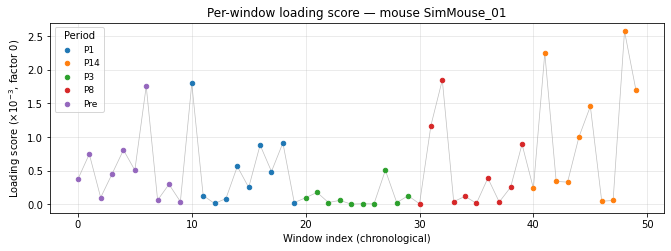

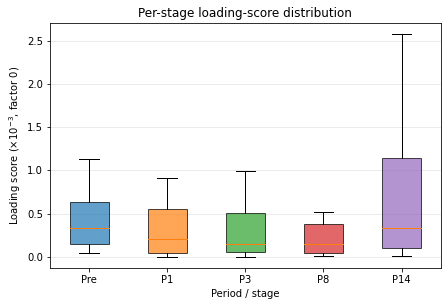

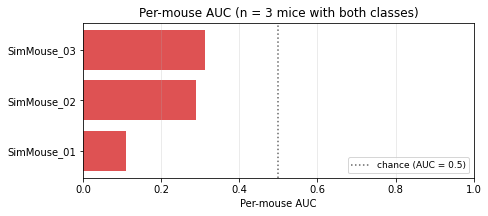

In [6]:
from electome.viz import (plot_per_mouse_timeseries,
                  plot_per_stage_boxplot,
                  plot_per_mouse_auc_bar)

plot_per_mouse_timeseries(scores, data['period'], data['mouse_id'],
                          mouse_id_to_show='SimMouse_01')
plt.show()

plot_per_stage_boxplot(scores, data['period'],
                       stages_order=['Pre', 'P1', 'P3', 'P8', 'P14'])
plt.show()

plot_per_mouse_auc_bar(aucs)
plt.show()


## Section 6. Element selection — scree plot

Once you've picked an EF, the next paper-figure question is *which* input features actually drive factor 0 (the supervised latent). To answer that, we need to look at the model's `W` matrix: dCSFA-NMF factorizes each input window `x` as `x ≈ W.T @ s`, where `s` is the `K`-dim latent code produced by the encoder and `W` (returned by `model.get_W_nmf()`) is the learned NMF dictionary of shape `(K, dim_in)`. Each row `W[k, :]` is the spatial-spectral pattern that latent factor `k` reconstructs back into feature space.

In this codebase `dim_in = 36 × n_freq` — 36 base channels (8 brain regions for power features + 28 region-pairs for coherence features) times the number of frequency bins (3 for the 3-band models, 54 for the 1-Hz models). So `W[0, :]` (factor 0 = the supervised one) is a vector of 108 (3-band) or 1944 (1-Hz) numbers, one per (channel × frequency) pair, telling you how strongly each combination contributes to that factor.

The scree plot below takes `W[0, :]`, sorts its entries from largest to smallest, and draws each entry at its rank position. **Triangles** mark power features (rows 0–7 of the 36-channel block); **circles** mark coherence features (rows 8–35). The three **green dashed vertical lines** mark how many sorted entries you need to cover 80 %, 90 %, and 95 % of factor 0's total squared-L2 energy — these are the natural cutoffs for "important features".

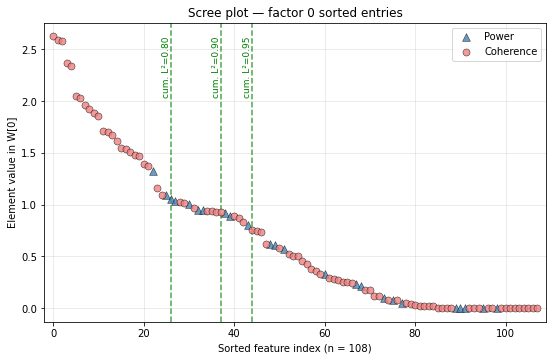

In [7]:
from electome.viz import plot_scree_W_nmf

plot_scree_W_nmf(model.get_W_nmf(), k=0,
                 thresholds=(0.8, 0.9, 0.95))
plt.show()


## Section 7. Element selection — dual-filter heatmap

Beyond the scree plot, the paper figures use a dual-filter view that
combines:

* **Absolute strength** — features whose cumulative squared-L2
  contribution to factor 0 is in the top 70 % (dark = strong; `abs_cum_ratio=0.7` below).
* **Relative uniqueness** — for each feature, the fraction of the
  inter-factor sum that is attributable to factor 0 (≥ 0.3 means
  factor 0 contributes at least 30 % of the inter-factor sum for that
  feature; `rel_val=0.3` below).

`plot_dual_filter(model, train_dict)` runs both filters via
`process_W_nmf_dual_filter` and then chooses the appropriate heatmap
style automatically:

* **3-band model (3 frequency columns)** → **bar heatmap** —
  bar length encodes absolute strength, bar color encodes relative
  uniqueness.
* **1-Hz model (54 frequency columns)** → **dot heatmap** —
  bars would be too narrow to read with 54 columns, so dot size encodes
  absolute strength and dot color encodes relative uniqueness instead.

Both styles use the same Iowa-Gold border to mark features that pass
*both* filters simultaneously.

### 7a. 3-band → bar heatmap

absolute intensity range: 0 - 2.626039
relative uniqueness range: 0.0000 - 0.4132


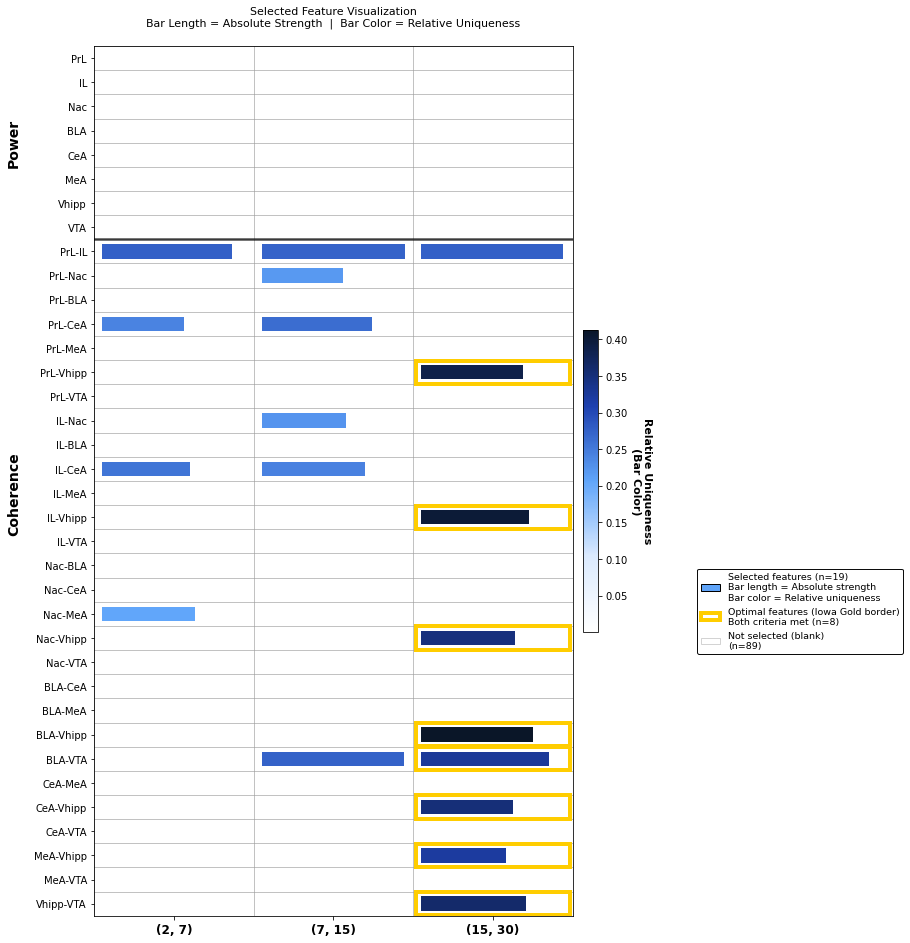

In [8]:
from electome.viz import plot_dual_filter

fig, *_ = plot_dual_filter(model, data,
                           abs_cum_ratio=0.7,
                           rel_val=0.3)
plt.show()


### 7b. 1-Hz → dot heatmap

Now load the 1-Hz Maternal-Engagement EF (same task, but with 54 × 1-Hz
frequency bins instead of 3 wide bands) and re-run the same one-line
wrapper — `plot_dual_filter` automatically switches to the dot heatmap
because the number of frequency columns is > 10.

absolute intensity range: 0 - 2.532099
relative uniqueness range: 0.0000 - 0.3304


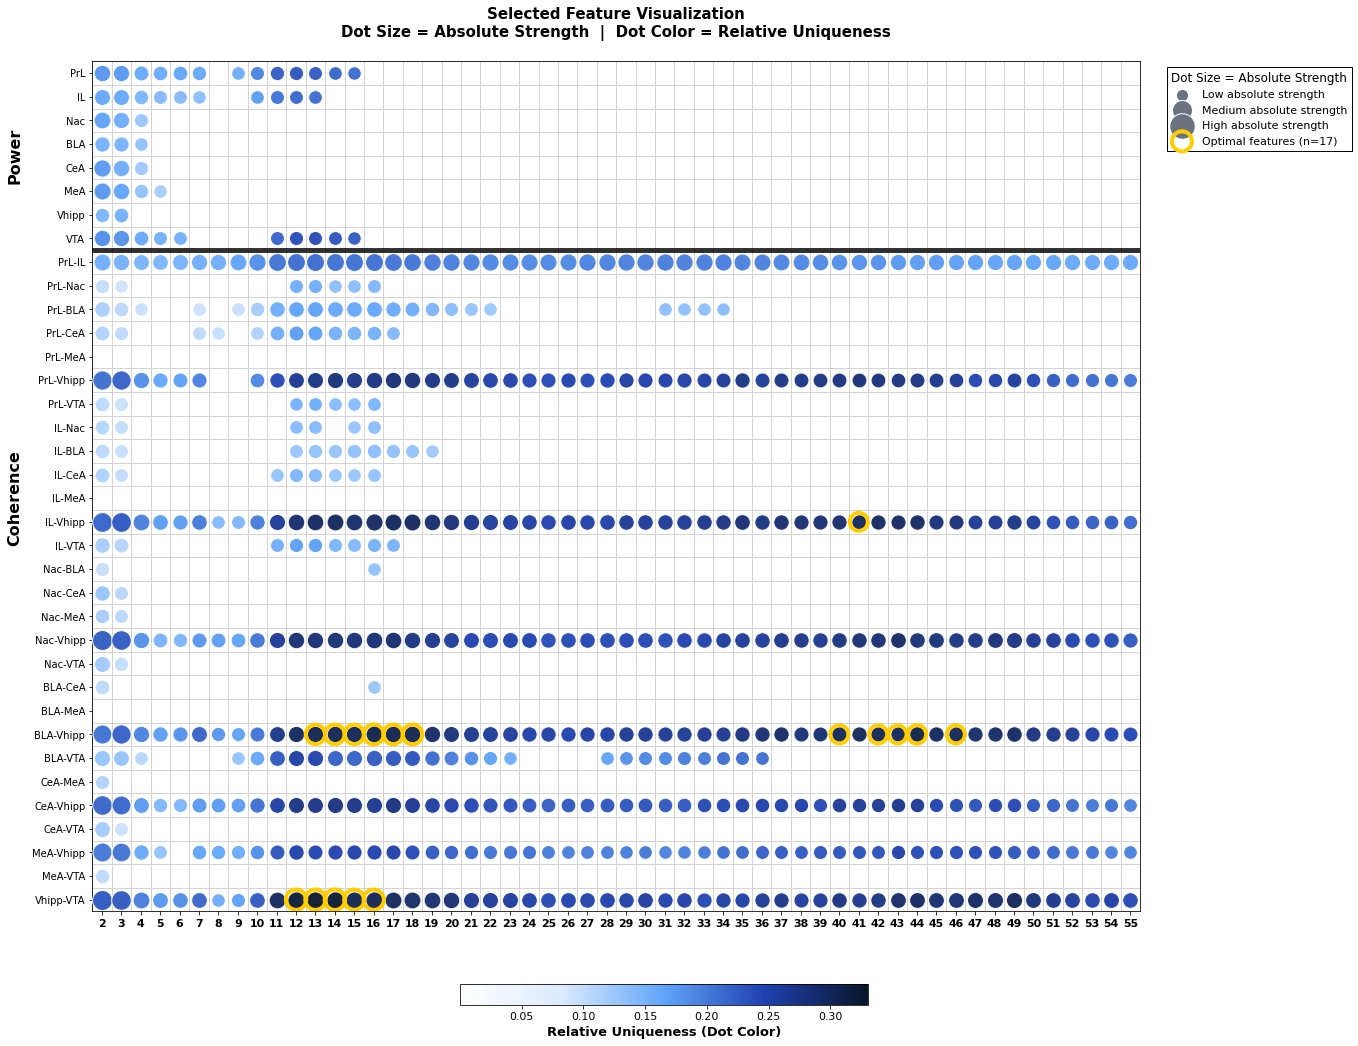

In [9]:
model_1hz = load_ef_model('OnnestVsOffnest_1Hz')
data_1hz  = load_demo_data('1Hz')

fig, *_ = plot_dual_filter(model_1hz, data_1hz,
                           abs_cum_ratio=0.7,
                           rel_val=0.3)
plt.show()
